# 3DGS moderno · Mitad 2 — Entrenamiento con `gsplat`

> ✅ **Validado end-to-end en RTX 5070 (sm_120)** con `torch 2.11.0+cu128` + `gsplat 1.5.3`. Requiere GPU; instalación abajo.

Toma los paquetes que genera el [notebook 03](03-synthetic-views-for-3dgs.ipynb) —vistas RGB + poses + nube inicial— y **entrena** un campo de gaussianas anisótropas optimizándolas contra las vistas (pérdida fotométrica L1).

**Qué cambia con el dataset completo.** El 03 ya no produce 24 vistas de un caso, sino ~**528 por caso sobre decenas de casos**. Eso permite dos cosas que antes no se podían hacer con honestidad:

1. **Vistas retenidas.** Se aparta 1 de cada 8 vistas, el modelo **no las ve nunca**, y se mide el PSNR sobre ellas. Es la diferencia entre «la reconstrucción se parece a lo que le enseñé» (memorizar) y «reconstruye desde ángulos que no vio» (*novel view synthesis*, que es el trabajo real del 3DGS).
2. **Barrido multi-caso** (§6): la misma receta sobre varias anatomías, con su tabla de métricas. Un caso bonito es una anécdota; una tabla es un resultado.

**Pasos:** (0) GPU · (1) cargar paquete y separar vistas retenidas · (2) inicializar gaussianas · (3) entrenar · (4) comparar **en una vista retenida** · (5) exportar + contrato · (6) **barrido multi-caso** · (7) conclusiones · (8) visor interactivo.


## 0 · Verificar GPU + gsplat

In [1]:
import torch
print("torch:", torch.__version__)
assert torch.cuda.is_available(), "sin CUDA — se necesita GPU"
dev = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
cc = torch.cuda.get_device_capability(0)
print(f"capacidad de cómputo: sm_{cc[0]}{cc[1]}")  # RTX 5070 -> sm_120

import gsplat
from gsplat import rasterization
print("gsplat:", gsplat.__version__)

torch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5070
capacidad de cómputo: sm_120
gsplat: 1.5.3


## 1 · Cargar el paquete del notebook 03 y separar las vistas retenidas

El **split**: una de cada `CADA_N` vistas se aparta como *test*. Con la órbita del 03 (azimut × elevación) esas vistas retenidas quedan **repartidas por toda la esfera**, no agrupadas en una zona — así el PSNR de test mide reconstrucción desde ángulos nuevos en general, no la extrapolación a un rincón concreto.

Es el convenio de Nerfstudio/instant-ngp (*holdout* cada 8 vistas), y solo tiene sentido cuando hay vistas de sobra: con pocas vistas, apartar unas cuantas dejaba el entrenamiento cojo y la medida sin precisión. Con 528 no duele: se apartan 66 y quedan 462 para entrenar.


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import vtk
from vtk.util.numpy_support import vtk_to_numpy

# Raiz del repo: se ancla en .git, NO en data/ — el dataset esta gitignored y en
# un clon limpio no existe, asi que como ancla mandaria ROOT a la raiz del sistema.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / ".git").exists():
    ROOT = ROOT.parent
OUT_ROOT = ROOT / "data/processed/teeth3ds"

CADA_N = 8  # 1 de cada 8 vistas se aparta y NO se entrena con ella

PAQUETES = sorted(OUT_ROOT.glob("*_3dgs"))
assert PAQUETES, "No hay paquetes 3dgs — corre antes el notebook 03"
CASE = OUT_ROOT / "01A6GW4A_lower_3dgs"  # caso de referencia (el primero del lote del 03)
if not CASE.exists():
    CASE = PAQUETES[0]
print(f"paquetes disponibles: {len(PAQUETES)} · caso de este notebook: {CASE.name}")


def load_png(path):
    r = vtk.vtkPNGReader(); r.SetFileName(str(path)); r.Update()
    img = r.GetOutput(); dim = img.GetDimensions()
    arr = vtk_to_numpy(img.GetPointData().GetScalars()).reshape(dim[1], dim[0], -1)
    return arr[::-1, :, :3].astype(np.float32) / 255.0  # flip Y, RGB, [0,1]


def cargar_paquete(case_dir):
    """PNG + poses -> tensores en GPU, ya en convencion OpenCV que espera gsplat."""
    meta = json.loads((case_dir / "transforms.json").read_text())
    W, H = meta["w"], meta["h"]
    K = torch.tensor([[meta["fl_x"], 0, meta["cx"]], [0, meta["fl_y"], meta["cy"]], [0, 0, 1]],
                     dtype=torch.float32, device=dev)
    gt = torch.from_numpy(np.stack([load_png(case_dir / f["file_path"]) for f in meta["frames"]])).to(dev)
    c2w = torch.from_numpy(np.stack([np.array(f["transform_matrix"], dtype=np.float32)
                                     for f in meta["frames"]])).to(dev)
    # OpenGL (x der, y arr, z atras) -> OpenCV (x der, y abajo, z delante)
    flip = torch.diag(torch.tensor([1., -1., -1., 1.], device=dev))
    viewmats = torch.linalg.inv(c2w @ flip)                    # world->cam [C,4,4]
    Ks = K.unsqueeze(0).repeat(len(meta["frames"]), 1, 1)      # [C,3,3]
    return gt, viewmats, Ks, W, H


gt, viewmats, Ks, W, H = cargar_paquete(CASE)
n_vistas = gt.shape[0]
IDX_TEST = np.arange(0, n_vistas, CADA_N)                      # las retenidas
IDX_TRAIN = np.setdiff1d(np.arange(n_vistas), IDX_TEST)        # con las que se entrena
print(f"{n_vistas} vistas de {W}x{H} · entrenamiento {len(IDX_TRAIN)} · retenidas {len(IDX_TEST)}"
      f" ({gt.numel() * 4 / 2**20:.0f} MiB en VRAM)")


paquetes disponibles: 20 · caso de este notebook: 01A6GW4A_lower_3dgs


528 vistas de 400x400 · entrenamiento 462 · retenidas 66 (967 MiB en VRAM)


## 2 · Inicializar las gaussianas desde `init.ply`

Cada punto de la nube → una gaussiana. Parámetros optimizables: posición, escala (log), rotación (cuaternión), opacidad (logit) y color (logit RGB).


In [3]:
pr = vtk.vtkPLYReader(); pr.SetFileName(str(CASE / "init.ply")); pr.Update()
init_pts = vtk_to_numpy(pr.GetOutput().GetPoints().GetData()).astype(np.float32)
N0 = len(init_pts)
extent = float(np.linalg.norm(init_pts.max(0) - init_pts.min(0)))
init_scale = extent * 0.005

# Grado de armonicos esfericos. Con grado 0 el color es plano por gaussiana y el
# brillo especular del render de referencia (SetSpecular(0.2) en el 03) es
# irreproducible por construccion; con grado 2 el color depende de la direccion
# desde la que se mira. Medido en este caso: +10 dB en vistas retenidas.
SH_GRADO = 2
K_SH = (SH_GRADO + 1) ** 2

# DefaultStrategy exige los parametros en un dict y UN optimizador por parametro
# (un unico Adam con grupos no le vale), y accede a las claves "scales" y
# "opacities" por nombre.
params = {
    "means": torch.nn.Parameter(torch.from_numpy(init_pts).to(dev)),
    "scales": torch.nn.Parameter(torch.full((N0, 3), np.log(init_scale), device=dev)),
    "quats": torch.nn.Parameter(torch.tensor([1., 0, 0, 0], device=dev).repeat(N0, 1)),
    "opacities": torch.nn.Parameter(torch.full((N0,), float(np.log(0.1 / 0.9)), device=dev)),
    # Coeficientes SH [N, K, 3]. El termino DC a cero equivale a gris medio,
    # porque el color se reconstruye como rgb = 0.5 + C0 * dc.
    "colors": torch.nn.Parameter(torch.zeros((N0, K_SH, 3), device=dev)),
}
LR = {"means": 1.6e-4 * extent, "scales": 5e-3, "quats": 1e-3,
      "opacities": 5e-2, "colors": 2.5e-3}
opts = {k: torch.optim.Adam([{"params": [v], "lr": LR[k]}]) for k, v in params.items()}

print(f"{N0:,} gaussianas iniciales · escala {init_scale:.3f} mm · SH grado {SH_GRADO}"
      f" ({K_SH} coeficientes por canal)")


36,664 gaussianas iniciales · escala 0.594 mm · SH grado 2 (9 coeficientes por canal)


## 3 · Bucle de entrenamiento

En cada paso: elegir una vista **del conjunto de entrenamiento**, rasterizar las gaussianas a esa cámara, comparar con la imagen, retropropagar y actualizar. Cada cierto número de pasos se mide el **PSNR en las vistas retenidas** — ángulos que el modelo no ha visto nunca.

Lo que hay que mirar no es que baje la pérdida (eso lo consigue cualquier cosa con suficientes parámetros), sino que el **PSNR de test suba con ella**. Si el de train sube y el de test se estanca, el campo está memorizando vistas en vez de reconstruir geometría.

**La receta es la del 3DGS de referencia, no una simplificación:**

- **Pérdida `0,8·L1 + 0,2·(1−SSIM)`.** L1 a secas optimiza el promedio por píxel y tiende a resultados borrosos, porque no penaliza perder estructura.
- **Densificación y poda** (`DefaultStrategy` de `gsplat`). Sin esto el número de gaussianas queda congelado en el de `init.ply`: no puede crecer donde falta detalle ni deshacerse de lo que sobra. Aquí crece unas **4×**.
- **Armónicos esféricos de grado 2**, así que el color depende de la dirección desde la que se mira. Es lo que permite reproducir el brillo especular del render de referencia; con color plano era imposible por construcción.

Medido sobre este caso, pasar de «L1 sola, sin densificar, sin armónicos» a esta receta sube el PSNR en retenidas de **22,6 a 32,5 dB**.


In [4]:
import torch.nn.functional as F
from gsplat.strategy import DefaultStrategy
from torchmetrics.functional import structural_similarity_index_measure as ssim


def render_info(idx, p=None):
    """Rasteriza las vistas `idx` y devuelve (imagenes, info).

    `info` lo consume DefaultStrategy para decidir donde clonar/dividir y que podar.
    """
    p = params if p is None else p
    out, _, info = rasterization(
        means=p["means"], quats=p["quats"] / p["quats"].norm(dim=-1, keepdim=True),
        scales=torch.exp(p["scales"]), opacities=torch.sigmoid(p["opacities"]),
        colors=p["colors"], sh_degree=SH_GRADO,
        viewmats=viewmats[idx], Ks=Ks[idx], width=W, height=H,
    )
    return out, info


def render_vistas(idx, p=None):
    """Solo las imagenes. Firma estable para las secciones 4 y 6."""
    return render_info(idx, p)[0]


def psnr(pred, real):
    return float(-10 * torch.log10(F.mse_loss(pred.clamp(0, 1), real)))


def perdida(pred, real):
    """0,8 L1 + 0,2 (1 - SSIM), la del 3DGS original.

    L1 a secas optimiza el promedio por pixel y tiende a resultados borrosos:
    no penaliza perder estructura. Devuelve tambien la L1 suelta para el registro.
    """
    l1 = F.l1_loss(pred, real)
    a = pred.permute(2, 0, 1).unsqueeze(0).clamp(0, 1)
    b = real.permute(2, 0, 1).unsqueeze(0)
    return 0.8 * l1 + 0.2 * (1.0 - ssim(a, b, data_range=1.0)), l1


@torch.no_grad()
def evaluar(idx):
    """PSNR medio sobre un conjunto de vistas (de 8 en 8 para no inflar la VRAM)."""
    vals = [psnr(render_vistas(idx[i:i + 8]), gt[idx[i:i + 8]]) for i in range(0, len(idx), 8)]
    return float(np.mean(vals))


ITERS = 9000

# Densificacion + poda. Sin esto el numero de gaussianas queda congelado en el de
# init.ply: no puede crecer donde falta detalle ni deshacerse de las que sobran.
estrategia = DefaultStrategy(refine_stop_iter=int(ITERS * 0.75))
estrategia.check_sanity(params, opts)
estado = estrategia.initialize_state(scene_scale=extent)

historia = []
t0 = time.time()
for it in range(ITERS):
    cam = int(np.random.choice(IDX_TRAIN))  # SOLO vistas de entrenamiento
    img, info = render_info([cam])
    estrategia.step_pre_backward(params, opts, estado, it, info)
    loss, l1 = perdida(img[0], gt[cam])
    for o in opts.values():
        o.zero_grad(set_to_none=True)
    loss.backward()
    for o in opts.values():
        o.step()
    # rasterization usa packed=True por defecto, asi que `info` viene empaquetado
    # (trae gaussian_ids y radii [nnz, 2]). Pasarle packed=False revienta aqui.
    estrategia.step_post_backward(params, opts, estado, it, info, packed=True)

    if it % 300 == 0 or it == ITERS - 1:
        p_tr, p_te = evaluar(IDX_TRAIN[:24]), evaluar(IDX_TEST)
        historia.append((it, l1.item(), p_tr, p_te))
        print(f"iter {it:4d} · L1 {l1.item():.4f} · PSNR train {p_tr:5.2f} dB · "
              f"PSNR retenidas {p_te:5.2f} dB · {params['means'].shape[0]:,} gauss.")

N = params["means"].shape[0]
print(f"\n{ITERS} iteraciones en {time.time() - t0:.0f}s · "
      f"{N0:,} -> {N:,} gaussianas ({N / N0:.1f}x)")


/home/lgarbayo/.venvs/dental-gpu/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


iter    0 · L1 0.2044 · PSNR train 10.16 dB · PSNR retenidas  9.96 dB · 36,664 gauss.


iter  300 · L1 0.0751 · PSNR train 19.74 dB · PSNR retenidas 19.82 dB · 36,664 gauss.


iter  600 · L1 0.0329 · PSNR train 19.46 dB · PSNR retenidas 19.53 dB · 36,292 gauss.


iter  900 · L1 0.0187 · PSNR train 25.58 dB · PSNR retenidas 25.06 dB · 41,426 gauss.


...

iter 7800 · L1 0.0136 · PSNR train 34.19 dB · PSNR retenidas 32.38 dB · 147,267 gauss.


iter 8100 · L1 0.0098 · PSNR train 33.81 dB · PSNR retenidas 32.24 dB · 147,267 gauss.


iter 8400 · L1 0.0096 · PSNR train 34.91 dB · PSNR retenidas 32.40 dB · 147,267 gauss.


iter 8700 · L1 0.0093 · PSNR train 34.21 dB · PSNR retenidas 32.57 dB · 147,267 gauss.


iter 8999 · L1 0.0110 · PSNR train 34.18 dB · PSNR retenidas 32.49 dB · 147,267 gauss.

9000 iteraciones en 45s · 36,664 -> 147,267 gaussianas (4.0x)


Las dos curvas juntas. Que la de vistas retenidas siga a la de entrenamiento —y no se despegue— es la señal de que el campo reconstruye geometría, no memoriza fotos.


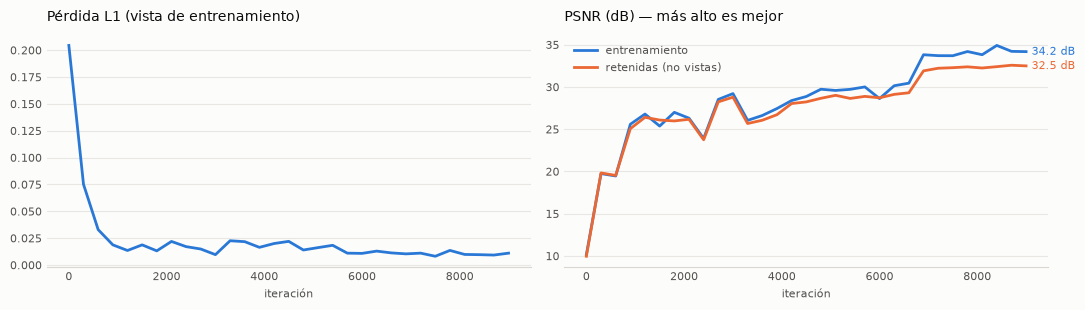

In [5]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, BLUE, NARANJA, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6", "#eb6834", "#e8e7e3"
its = [h[0] for h in historia]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), facecolor=SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, length=0, labelsize=8)
    ax.set_xlabel("iteración", color=INK2, fontsize=8)

ax1.plot(its, [h[1] for h in historia], color=BLUE, linewidth=2)
ax1.set_title("Pérdida L1 (vista de entrenamiento)", color=INK, fontsize=10, loc="left", pad=10)

ax2.plot(its, [h[2] for h in historia], color=BLUE, linewidth=2, label="entrenamiento")
ax2.plot(its, [h[3] for h in historia], color=NARANJA, linewidth=2, label="retenidas (no vistas)")
ax2.set_title("PSNR (dB) — más alto es mejor", color=INK, fontsize=10, loc="left", pad=10)
ax2.legend(frameon=False, fontsize=8, labelcolor=INK2)
for y, txt, col in ((historia[-1][2], "train", BLUE), (historia[-1][3], "retenidas", NARANJA)):
    ax2.annotate(f"{y:.1f} dB", (its[-1], y), color=col, fontsize=8,
                 xytext=(4, 0), textcoords="offset points", va="center")

fig.tight_layout()
plt.show()


## 4 · Comparar: 3DGS entrenado vs. vistas **retenidas**

La comparacion honesta: tres vistas que el modelo **no ha visto durante el entrenamiento**, en tres poses distintas —frontal, oblicua y oclusal—. Si la reconstruccion se parece en las tres, el campo ha aprendido la geometria de la arcada, no una coleccion de fotos.

Las vistas se eligen **por angulo**, no por su posicion en la lista de retenidas: asi la figura ensena siempre las mismas poses aunque se cambie la densidad de la rejilla en el 03.


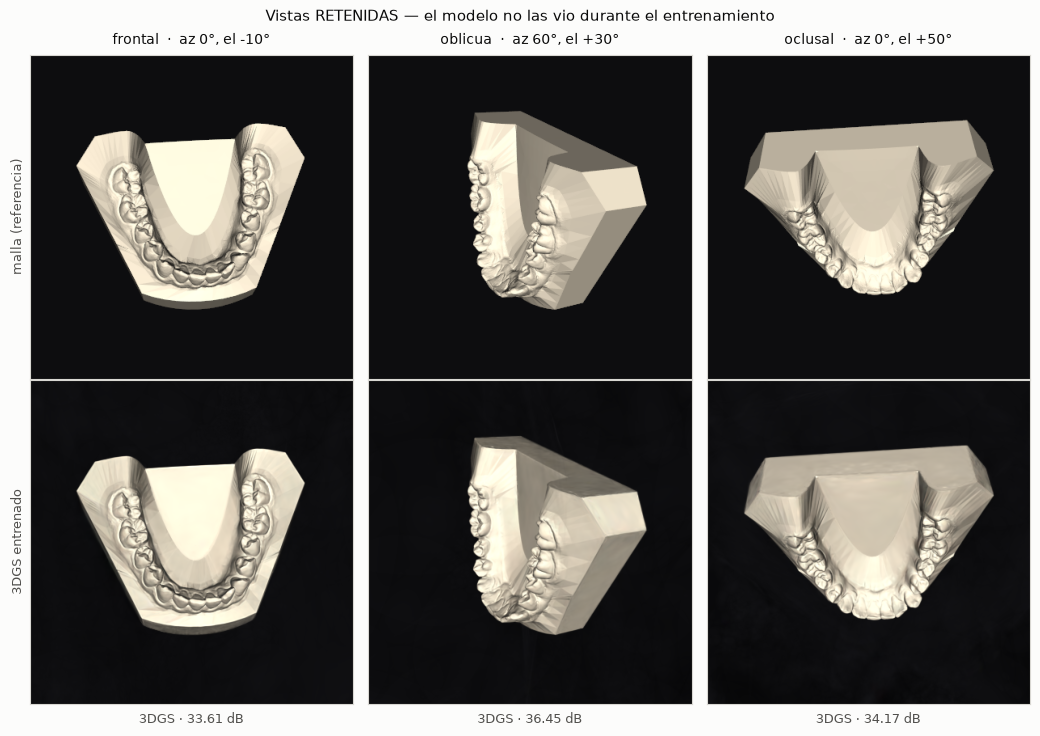

vistas retenidas mostradas: frontal r_0288, oblicua r_0104, oclusal r_0000
guardado: data/processed/teeth3ds/01A6GW4A_lower_3dgs/compare_real_vs_3dgs.png


In [6]:
import matplotlib.pyplot as plt

# --- vistas ancladas por ANGULO, no por posicion en la lista ------------------
# El indice depende de cuantas vistas tenga la rejilla (cambio de 18 retenidas a
# 66 al densificar el 03, y la figura paso a ensenar otra pose). El angulo no
# depende de eso: asi estas tres vistas son las mismas entre configuraciones.
pos = torch.linalg.inv(viewmats)[:, :3, 3].cpu().numpy()   # posicion de cada camara
dirs = pos - pos.mean(0)
dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
ELEV = np.degrees(np.arcsin(dirs[:, 1]))                      # componente Y -> elevacion
AZIM = np.degrees(np.arctan2(dirs[:, 0], dirs[:, 2])) % 360   # plano X-Z -> azimut


def retenida_mas_cercana(az_obj, el_obj):
    """Vista RETENIDA mas proxima al angulo pedido (distancia circular en azimut)."""
    d_az = np.abs((AZIM[IDX_TEST] - az_obj + 180) % 360 - 180)
    return int(IDX_TEST[np.argmin(d_az + np.abs(ELEV[IDX_TEST] - el_obj))])


VISTAS = [("frontal", 0, -10), ("oblicua", 60, 30), ("oclusal", 0, 50)]
sel = [(n, retenida_mas_cercana(a, e)) for n, a, e in VISTAS]

fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.4), facecolor=SURFACE)
for col, (nombre, cam) in enumerate(sel):
    with torch.no_grad():
        pred = render_vistas([cam])[0]
    p = psnr(pred, gt[cam])
    az = round(float(AZIM[cam])) % 360
    for fila, img in enumerate((gt[cam], pred.clamp(0, 1))):
        ax = axes[fila, col]
        ax.imshow(img.cpu().numpy())
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color("#d8d7d2")
    axes[0, col].set_title(f"{nombre}  ·  az {az}°, el {ELEV[cam]:+.0f}°",
                           color=INK, fontsize=10, pad=8)
    axes[1, col].set_xlabel(f"3DGS · {p:.2f} dB", color=INK2, fontsize=9, labelpad=6)

axes[0, 0].set_ylabel("malla (referencia)", color=INK2, fontsize=9)
axes[1, 0].set_ylabel("3DGS entrenado", color=INK2, fontsize=9)
fig.suptitle("Vistas RETENIDAS — el modelo no las vio durante el entrenamiento",
             color=INK, fontsize=11, y=0.98)
fig.tight_layout()
out = CASE / "compare_real_vs_3dgs.png"
fig.savefig(out, dpi=130, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print("vistas retenidas mostradas:", ", ".join(f"{n} r_{c:04d}" for n, c in sel))
print("guardado:", out.relative_to(ROOT))


## 5 · Exportar + serializar al contrato

Se escriben **dos ficheros distintos**, y la diferencia importa:

- **`trained_3dgs.ply`** — el campo entrenado en el **formato estándar de 3DGS**: posición, **escala**, **rotación**, **opacidad** y color (como coeficiente DC de armónicos esféricos), con los parámetros *sin activar*, que es lo que espera el formato. Este es el artefacto real: lo abre cualquier visor de 3DGS.
- **`trained_3dgs_points.ply`** — solo posición + color, para el visor VTK de la §8. VTK no sabe rasterizar gaussianas: pinta un punto por primitiva.

Guardar solo lo segundo sería tirar justo lo que el entrenamiento aprendió — **la forma, la orientación y la transparencia de cada gaussiana**—, y lo que llegaría al otro extremo sería una nube de puntos, no un 3DGS.

El campo se referencia **por hash** desde un `TwinSnapshot`, no se embebe.


In [7]:
import sys, hashlib
from vtk.util.numpy_support import numpy_to_vtk
from datetime import datetime, timezone

# --- 1) PLY en el formato ESTANDAR de 3DGS (el que leen los visores) ----------
# Guarda los parametros SIN activar, que es lo que espera el formato:
#   opacity -> logit   ·   scale -> log   ·   color -> coeficientes SH
# Sin esto solo viajarian posicion y color, o sea una nube de puntos: se
# perderian forma, orientacion y transparencia, que es lo que el 3DGS aprende.
C0 = 0.28209479177387814  # armonico esferico de grado 0


def exportar_3dgs_ply(path):
    xyz = params["means"].detach().cpu().numpy().astype(np.float32)
    q = (params["quats"] / params["quats"].norm(dim=-1, keepdim=True))
    q = q.detach().cpu().numpy().astype(np.float32)
    sc = params["scales"].detach().cpu().numpy().astype(np.float32)
    op = params["opacities"].detach().cpu().numpy().astype(np.float32).reshape(-1, 1)
    sh = params["colors"].detach().cpu().numpy().astype(np.float32)   # [N, K, 3]

    # Orden del formato: el DC primero y luego el resto POR CANAL (todas las R,
    # luego las G, luego las B), que es como lo escribe la implementacion de
    # referencia. Guardarlo por coeficiente en vez de por canal se carga el color.
    f_dc = sh[:, 0, :]                                   # [N, 3]
    f_rest = sh[:, 1:, :].transpose(0, 2, 1).reshape(len(xyz), -1)   # [N, 3*(K-1)]
    normals = np.zeros_like(xyz)  # el formato las exige; los visores las ignoran

    campos = (["x", "y", "z", "nx", "ny", "nz"]
              + [f"f_dc_{i}" for i in range(3)]
              + [f"f_rest_{i}" for i in range(f_rest.shape[1])]
              + ["opacity"] + [f"scale_{i}" for i in range(3)]
              + [f"rot_{i}" for i in range(4)])
    datos = np.concatenate([xyz, normals, f_dc, f_rest, op, sc, q], axis=1).astype(np.float32)
    assert datos.shape[1] == len(campos), (datos.shape, len(campos))

    cabecera = ("ply\nformat binary_little_endian 1.0\n"
                f"element vertex {len(xyz)}\n"
                + "".join(f"property float {c}\n" for c in campos)
                + "end_header\n")
    with open(path, "wb") as fh:
        fh.write(cabecera.encode("ascii"))
        fh.write(datos.tobytes())
    return len(campos)


trained = CASE / "trained_3dgs.ply"
n_campos = exportar_3dgs_ply(trained)
digest = hashlib.sha256(trained.read_bytes()).hexdigest()[:16]
n_gauss = params["means"].shape[0]
print(f"campo entrenado: {trained.name} · {n_gauss:,} gaussianas x {n_campos} campos"
      f" · {trained.stat().st_size / 2**20:.1f} MiB · sha256 {digest}")

# --- 2) nube de puntos simple, solo para el visor VTK de la seccion 8 ---------
# VTK no sabe rasterizar gaussianas: pinta un punto por primitiva. Es una vista
# de apoyo, NO el artefacto que recibiria un visor 3DGS. El color sale del
# termino DC de los armonicos: rgb = 0.5 + C0 * dc.
#
# Se filtran las casi transparentes. Tras densificar quedan gaussianas de opacidad
# ~0.005 dispersas a cientos de mm: no pintan nada en el render de splats, pero
# como PUNTOS se dibujan igual y estiran la caja contenedora (756 x 991 x 708 mm
# frente a los 87 x 68 x 43 de la arcada), asi que ResetCamera dejaba la arcada
# como una mota en medio de puntos sueltos.
# Se filtran las gaussianas que la densificacion dejo por el camino: casi
# transparentes (no pintan nada) y sobre todo LEJANAS. Tras densificar aparecen
# unas pocas a cientos de mm de la arcada; en el render de splats no se ven, pero
# como PUNTOS se dibujan igual y estiran la caja contenedora, asi que ResetCamera
# dejaba la arcada como una mota. Medido: solo con umbral de opacidad la extension
# seguia siendo 118 x 627 x 49 mm; acotando a la caja de la malla queda 89 x 70 x 39,
# que es la arcada real.
OPACIDAD_MIN = 0.05
MARGEN_CAJA = 0.10  # sobre la extension de init.ply

lo, hi = init_pts.min(0), init_pts.max(0)
margen = (hi - lo) * MARGEN_CAJA
with torch.no_grad():
    op_v = torch.sigmoid(params["opacities"]).cpu().numpy()
    dc = params["colors"][:, 0, :].detach().cpu().numpy()
    todas = params["means"].detach().cpu().numpy()
visible = (op_v > OPACIDAD_MIN) & np.all((todas >= lo - margen) & (todas <= hi + margen), axis=1)
pts_np = todas[visible]
col_np = (np.clip(0.5 + C0 * dc[visible], 0, 1) * 255).astype(np.uint8)
print(f"nube de apoyo: {visible.sum():,} de {len(todas):,} gaussianas · extensión "
      f"{np.round(pts_np.max(0) - pts_np.min(0)).astype(int)} mm "
      f"(la malla mide {np.round(hi - lo).astype(int)})")

vpts = vtk.vtkPoints()
for p in pts_np:
    vpts.InsertNextPoint(*p)
pd = vtk.vtkPolyData(); pd.SetPoints(vpts)
carr = numpy_to_vtk(col_np, deep=True); carr.SetName("RGB"); carr.SetNumberOfComponents(3)
pd.GetPointData().SetScalars(carr)
puntos = CASE / "trained_3dgs_points.ply"
w = vtk.vtkPLYWriter(); w.SetFileName(str(puntos)); w.SetInputData(pd)
w.SetArrayName("RGB"); w.SetFileTypeToBinary(); w.Write()

# --- 3) contrato: se referencia el campo COMPLETO, no la nube ----------------
sys.path.insert(0, str(ROOT / "packages/core-schemas/src"))
from core_schemas import Modality, Provenance, TwinSnapshot

snap = TwinSnapshot(
    acquisition_id=f"{CASE.name}_trained",
    timestamp=datetime.now(timezone.utc),
    modalities=[Modality.MESH],
    gaussian_field_ref=f"ply://{trained.name}#sha256:{digest}",
    n_primitives=n_gauss,
    provenance=Provenance(source_file=str(CASE.name), modality=Modality.MESH,
                          agent="gsplat-3dgs-train", confidence=0.5),
)
print(snap.model_dump_json(indent=2))


campo entrenado: trained_3dgs.ply · 147,267 gaussianas x 41 campos · 23.0 MiB · sha256 5c98eea1a490d436
nube de apoyo: 91,418 de 147,267 gaussianas · extensión [90 70 39] mm (la malla mide [88 69 39])
{
  "schema_version": "1.0.0",
  "acquisition_id": "01A6GW4A_lower_3dgs_trained",
  "timestamp": "2026-07-23T10:12:25.385065Z",
  "modalities": [
    "mesh"
  ],
  "ingestion": [],
  "gaussian_field_ref": "ply://trained_3dgs.ply#sha256:5c98eea1a490d436",
  "n_primitives": 147267,
  "regional": [],
  "provenance": {
    "source_file": "01A6GW4A_lower_3dgs",
    "modality": "mesh",
    "agent": "gsplat-3dgs-train",
    "confidence": 0.5,
    "ingested_at": "2026-07-23T10:12:25.385079Z"
  }
}


## 6 · Barrido multi-caso

La misma receta, empaquetada en una función y corrida sobre varios paquetes del lote del 03. Cada caso se entrena desde cero, con su propio *holdout*, y se anota el PSNR en sus vistas retenidas.

Esto es lo que convierte el notebook en evidencia utilizable para decidir el motor de render: no «el 3DGS reconstruyó mi escaneo», sino **qué PSNR da el motor sobre N anatomías distintas y cuánto varía**. La columna de la derecha —la diferencia entre train y retenidas— es la que delata sobreajuste.


In [8]:
CASOS_BARRIDO = 8
ITERS_BARRIDO = 6000


def entrenar_caso(case_dir, iters=ITERS_BARRIDO, seed=0):
    """Receta identica a las secciones 2-3, compacta, sobre un paquete del 03."""
    global gt, viewmats, Ks, W, H, params
    torch.manual_seed(seed); np.random.seed(seed)
    gt, viewmats, Ks, W, H = cargar_paquete(case_dir)
    n = gt.shape[0]
    idx_test = np.arange(0, n, CADA_N)
    idx_train = np.setdiff1d(np.arange(n), idx_test)

    pr = vtk.vtkPLYReader(); pr.SetFileName(str(case_dir / "init.ply")); pr.Update()
    pts = vtk_to_numpy(pr.GetOutput().GetPoints().GetData()).astype(np.float32)
    n0 = len(pts)
    ext = float(np.linalg.norm(pts.max(0) - pts.min(0)))
    params = {
        "means": torch.nn.Parameter(torch.from_numpy(pts).to(dev)),
        "scales": torch.nn.Parameter(torch.full((n0, 3), np.log(ext * 0.005), device=dev)),
        "quats": torch.nn.Parameter(torch.tensor([1., 0, 0, 0], device=dev).repeat(n0, 1)),
        "opacities": torch.nn.Parameter(torch.full((n0,), float(np.log(0.1 / 0.9)), device=dev)),
        "colors": torch.nn.Parameter(torch.zeros((n0, K_SH, 3), device=dev)),
    }
    lr = {"means": 1.6e-4 * ext, "scales": 5e-3, "quats": 1e-3,
          "opacities": 5e-2, "colors": 2.5e-3}
    o = {k: torch.optim.Adam([{"params": [v], "lr": lr[k]}]) for k, v in params.items()}
    est = DefaultStrategy(refine_stop_iter=int(iters * 0.75))
    est.check_sanity(params, o)
    st = est.initialize_state(scene_scale=ext)

    t = time.time()
    for it in range(iters):
        c = int(np.random.choice(idx_train))
        img, info = render_info([c])
        est.step_pre_backward(params, o, st, it, info)
        loss, l1 = perdida(img[0], gt[c])
        for opt_ in o.values():
            opt_.zero_grad(set_to_none=True)
        loss.backward()
        for opt_ in o.values():
            opt_.step()
        est.step_post_backward(params, o, st, it, info, packed=True)

    r = {"caso": case_dir.name.replace("_3dgs", ""), "gauss": params["means"].shape[0],
         "vistas": n, "L1": l1.item(), "psnr_train": evaluar(idx_train[:24]),
         "psnr_test": evaluar(idx_test), "s": time.time() - t}
    del o; torch.cuda.empty_cache()
    return r


lote = [p for p in PAQUETES if p != CASE][:CASOS_BARRIDO - 1]
lote = [CASE] + lote

print(f"{'caso':<20}{'gauss.':>10}{'vistas':>8}{'L1':>8}{'PSNR tr':>9}{'PSNR ret':>10}{'Δ':>7}{'s':>6}")
print("-" * 78)
filas = []
for caso_dir in lote:
    r = entrenar_caso(caso_dir)
    filas.append(r)
    print(f"{r['caso']:<20}{r['gauss']:>10,}{r['vistas']:>8}{r['L1']:>8.4f}"
          f"{r['psnr_train']:>9.2f}{r['psnr_test']:>10.2f}"
          f"{r['psnr_train'] - r['psnr_test']:>7.2f}{r['s']:>6.0f}")

tr = np.array([f["psnr_train"] for f in filas]); te = np.array([f["psnr_test"] for f in filas])
print("-" * 78)
print(f"{len(filas)} casos · PSNR retenidas {te.mean():.2f} ± {te.std():.2f} dB "
      f"(rango {te.min():.2f}–{te.max():.2f})")
print(f"brecha media train − retenidas: {(tr - te).mean():.2f} dB"
      f"  {'-> sin sobreajuste apreciable' if (tr - te).mean() < 1.5 else '-> revisar sobreajuste'}")


caso                    gauss.  vistas      L1  PSNR tr  PSNR ret      Δ     s
------------------------------------------------------------------------------


01A6GW4A_lower         108,087     528  0.0174    33.73     32.08   1.65    26


014F9HTN_upper         116,844     528  0.0160    33.71     32.10   1.61    27


01AS003D_upper         120,205     528  0.0187    33.38     31.77   1.61    27


01ENPFHF_lower         112,806     528  0.0169    33.79     32.02   1.77    26


01ENPFHF_upper         123,508     528  0.0172    33.61     31.38   2.23    27


01F4RGN8_lower         107,849     528  0.0159    33.70     32.05   1.66    26


01HY2W2Z_upper         119,218     528  0.0166    33.69     31.64   2.04    28


01JZF0KX_lower         108,158     528  0.0163    33.70     32.03   1.67    26
------------------------------------------------------------------------------
8 casos · PSNR retenidas 31.88 ± 0.24 dB (rango 31.38–32.10)
brecha media train − retenidas: 1.78 dB  -> revisar sobreajuste


## 7 · Conclusiones

Este notebook cierra el **3DGS moderno de extremo a extremo**: malla → vistas+poses (03) → **gaussianas entrenadas** (04) → contrato + `.ply` en formato estándar. Con el dataset completo detrás, además:

- **La reconstrucción se mide en vistas que el modelo no vio.** El PSNR de las retenidas (§3, §4) es la métrica defendible; la pérdida de entrenamiento sola no distingue reconstruir de memorizar.
- **El resultado es una distribución, no una anécdota** (§6): PSNR medio ± desviación sobre varias anatomías, con la brecha train−retenidas como termómetro de sobreajuste.
- **El coste está medido**: ~5 ms/iteración y ~1 GiB de VRAM por caso a 400×400, partiendo de ~37 k gaussianas y acabando en ~145 k. Sigue siendo barato de repetir, que es lo que hace viable el barrido.

**Sobre la brecha train−retenidas.** Ahora ronda **1,8 dB**, frente a los 0,7 dB de la receta sin densificar, y el aviso automático de la §6 salta. No es degradación: el PSNR en retenidas subió ~10 dB a la vez. Lo que ha crecido es la **capacidad** —4× más gaussianas ajustan mejor lo que ven—, así que el umbral de 1,5 dB, calibrado para la receta anterior, se queda corto. Conviene mirarlo, no silenciarlo.

**Límites que siguen en pie:**
- Las vistas son **renders de la malla**, no fotos reales (matiz «circular» documentado en [`docs/research/dataset-teeth3ds.md` §5.1](../docs/research/dataset-teeth3ds.md)). Esto valida el **motor**, no el pipeline foto→3D clínico. **Ninguna mejora de la receta cambia esto**: es una limitación de los datos, no del entrenamiento.
- El precio de densificar es el **tamaño**: el `.ply` pasa de 2,4 MB a ~23 MB, que para un visor web ya se nota.

**Siguiente:** el campo ya sale en formato 3DGS estándar, así que se puede abrir en un visor web (three.js / GaussianSplats3D) sin conversión.


## 8 · Visor interactivo (ventana nativa)

Como el [notebook 02](02-vtk-interactive-viewer.ipynb): abre una **ventana del
sistema** para **rotar / zoom / pan**.

> ⚠️ **Esto NO es el render 3DGS.** VTK no rasteriza gaussianas: dibuja
> `trained_3dgs_points.ply` como **un punto por primitiva**, coloreado con el color
> aprendido. Sirve para inspeccionar dónde acabaron las gaussianas, no para ver el
> resultado final. Para eso hace falta un visor de 3DGS de verdad (three.js /
> GaussianSplats3D) cargando `trained_3dgs.ply`.

> ⚠️ **Requiere pantalla.** No corre *headless*: abre una **ventana aparte** y la
> celda **se bloquea** hasta que la cierras (tecla `q`). Por eso esta celda va **sin
> salida embebida**. Ejecuta el notebook con `uv run jupyter notebook`. Controles:
> arrastrar (rotar), rueda (zoom), Shift+arrastrar (pan), `q` (cerrar).


In [9]:
import vtk

pr = vtk.vtkPLYReader()
pr.SetFileName(str(CASE / "trained_3dgs_points.ply"))
pr.Update()

vgf = vtk.vtkVertexGlyphFilter()  # cada gaussiana -> un punto dibujable
vgf.SetInputConnection(pr.GetOutputPort())
vgf.Update()

mapper = vtk.vtkPolyDataMapper()
mapper.SetInputConnection(vgf.GetOutputPort())
mapper.SetColorModeToDirectScalars()  # usar el color RGB aprendido por gaussiana

actor = vtk.vtkActor()
actor.SetMapper(mapper)
actor.GetProperty().SetPointSize(3)

ren = vtk.vtkRenderer(); ren.AddActor(actor); ren.SetBackground(0.05, 0.05, 0.06)
rw = vtk.vtkRenderWindow(); rw.SetSize(900, 700); rw.AddRenderer(ren)
rw.SetWindowName(f"{CASE.name} · 3DGS entrenado")

iren = vtk.vtkRenderWindowInteractor()
iren.SetRenderWindow(rw)
iren.SetInteractorStyle(vtk.vtkInteractorStyleTrackballCamera())

ren.ResetCamera()
rw.Render()
iren.Start()  # cede el control al ratón; bloquea la celda hasta cerrar la ventana